In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
from diisco import names, DIISCO
import torch

timepoints = np.array([0, 5, 10, 15, 20, 25])
signal = np.array([0,0,1,1,1,1])

# 0 affected by: 2 pos
# 1 affected by: 0 pos
# 2 affected by: 1 neg
data = np.stack([[.2, .2, .6],
        [.2, .4, .4],
        [.25, .6, .15],
        [.3, .6, .1],
        [.4, .6, 0],
        [.45, .8, 0]], axis=0)
lambda_matrix = np.zeros((3, 3))
lambda_matrix[0,1] = 1
lambda_matrix[0,2] = 1
lambda_matrix[1,2] = 1
lambda_matrix[1,0] = 1
lambda_matrix[2,0] = 1
lambda_matrix[2,1] = 1

lambda_matrix = lambda_matrix.T
print(lambda_matrix)

[[0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 0.]]


In [2]:
seed = 8
np.random.seed(seed)

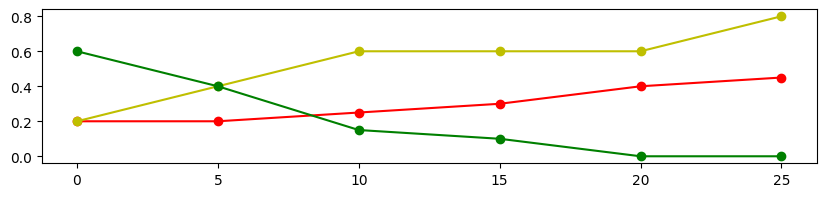

In [3]:
plt.figure(figsize = (10,2))
plt.plot(timepoints, data[:,0], '-ro')
plt.plot(timepoints, data[:,1], '-yo')
plt.plot(timepoints, data[:,2], '-go')
plt.show()

In [4]:
X = timepoints.reshape(-1, 1)
print(X)

lengthscale_f = np.mean(np.abs(X - X.T))
print(lengthscale_f)

j = int(lambda_matrix.sum(axis=1).max())
lengthscale_W = max([X[i, 0] - X[i-j+1, 0] for i in range(j-1, X.shape[0])])
print(lengthscale_W)

[[ 0]
 [ 5]
 [10]
 [15]
 [20]
 [25]]
9.722222222222221
5


In [5]:
print(X.shape)
timepoints = torch.tensor(X).float()
proportions = torch.tensor(data).float()
lambda_prior = torch.tensor(lambda_matrix).float()
signal_t = torch.tensor(signal.reshape(-1, 1)).float()
# z score the proportions
proportions_mean = proportions.mean(dim=0)
proportions_std = proportions.std(dim=0)
proportions = (proportions - proportions_mean)/ (proportions_std)

(6, 1)


In [6]:
print(signal_t)

tensor([[0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.]])


In [7]:
hyper_init_vals = {
    #names.LENGTHSCALE_F_1: lengthscale_f,
    #names.LENGTHSCALE_F_2: lengthscale_f,
    names.LENGTHSCALE_F: lengthscale_f,
    names.LENGTHSCALE_W: lengthscale_W,
    names.SIGMA_F: 0.5,
    names.VARIANCE_F: 1,
    names.SIGMA_W: 0.1,
    names.VARIANCE_W: 1,
    names.SIGMA_Y: 0.5,
}
print(hyper_init_vals)

{'lengthscale_f': 9.722222222222221, 'lengthscale_w': 5, 'sigma_f': 0.5, 'variance_f': 1, 'sigma_w': 0.1, 'variance_w': 1, 'sigma_y': 0.5}


In [8]:
def unscale(proportions, cluster_index): 
    return np.clip(proportions * 
                   proportions_std.detach().numpy()[cluster_index] + 
                   proportions_mean.detach().numpy()[cluster_index], 
                   0, None)

(6, 3)
fit alpha:  tensor([[-0.4361],
        [-0.4469],
        [ 0.1441],
        [-0.5623],
        [ 0.3856],
        [ 0.6219]])
fit alpha:  tensor([[-1.8927],
        [ 0.4526],
        [ 0.8471],
        [-0.1594],
        [-1.2059],
        [ 1.3739]])
fit alpha:  tensor([[ 1.6665],
        [-0.2457],
        [-0.5733],
        [ 0.4422],
        [-0.2907],
        [-0.2473]])
pred. alpha:  tensor([[-0.4361],
        [-0.4469],
        [ 0.1441],
        [-0.5623],
        [ 0.3856],
        [ 0.6219]])
pred. alpha:  tensor([[-1.8927],
        [ 0.4526],
        [ 0.8471],
        [-0.1594],
        [-1.2059],
        [ 1.3739]])
pred. alpha:  tensor([[ 1.6665],
        [-0.2457],
        [-0.5733],
        [ 0.4422],
        [-0.2907],
        [-0.2473]])
Set prior parameters: mean tensor([[[-0.8444],
         [-0.8417],
         [-0.5128],
         [ 0.1406],
         [ 0.8571],
         [ 1.2747]],

        [[-1.1406],
         [-0.7586],
         [ 0.1110],
         [ 0.362

  8%|▊         | 80/1000 [00:00<00:01, 732.36it/s]

fit alpha:  tensor([[ 0.6377],
        [ 0.0704],
        [-0.1117],
        [-0.9464],
        [ 0.0972],
        [ 0.4882],
        [-1.7429],
        [-0.1374],
        [ 0.5254],
        [-0.0289],
        [ 0.6108],
        [ 0.0187]], grad_fn=<CholeskySolveBackward0>)
fit alpha:  tensor([[-0.8487],
        [ 1.0879],
        [ 0.7174],
        [ 0.0812],
        [-0.8307],
        [ 1.4189],
        [-1.6166],
        [-0.4846],
        [ 0.7371],
        [-0.8237],
        [-0.4516],
        [ 0.1766]], grad_fn=<CholeskySolveBackward0>)
fit alpha:  tensor([[ 0.6874],
        [-0.6752],
        [-0.2479],
        [ 0.7036],
        [ 0.1853],
        [ 0.7716],
        [ 1.6840],
        [ 0.0598],
        [-0.8202],
        [ 0.2295],
        [-0.3011],
        [-1.4289]], grad_fn=<CholeskySolveBackward0>)
pred. alpha:  tensor([[ 0.6377],
        [ 0.0704],
        [-0.1117],
        [-0.9464],
        [ 0.0972],
        [ 0.4882],
        [-1.7429],
        [-0.1374],
        [

 23%|██▎       | 230/1000 [00:00<00:01, 694.83it/s]

fit alpha:  tensor([[ 0.6670],
        [ 0.1931],
        [ 0.5781],
        [-0.7539],
        [-0.0583],
        [ 0.3019],
        [-1.6974],
        [-0.1576],
        [-0.7272],
        [ 0.3902],
        [ 0.5384],
        [ 0.2312]], grad_fn=<CholeskySolveBackward0>)
fit alpha:  tensor([[-0.6648],
        [ 1.4060],
        [-0.0223],
        [-1.3275],
        [-2.5301],
        [-0.0796],
        [-1.4455],
        [-1.3135],
        [ 1.3365],
        [ 1.0718],
        [ 1.0472],
        [ 1.8183]], grad_fn=<CholeskySolveBackward0>)
fit alpha:  tensor([[ 0.4856],
        [-1.3132],
        [-0.8302],
        [-0.0426],
        [-0.3513],
        [ 0.6426],
        [ 1.5195],
        [ 1.2956],
        [-0.6101],
        [ 1.3827],
        [ 0.1644],
        [-1.3772]], grad_fn=<CholeskySolveBackward0>)
pred. alpha:  tensor([[ 0.6670],
        [ 0.1931],
        [ 0.5781],
        [-0.7539],
        [-0.0583],
        [ 0.3019],
        [-1.6974],
        [-0.1576],
        [

...

 79%|███████▉  | 790/1000 [00:01<00:00, 705.01it/s]

fit alpha:  tensor([[ 0.5554],
        [-0.1543],
        [-0.2831],
        [-0.7665],
        [ 0.2463],
        [ 0.1199],
        [-1.8354],
        [ 0.2535],
        [ 0.8109],
        [-0.0577],
        [-0.2224],
        [ 0.9018]], grad_fn=<CholeskySolveBackward0>)
fit alpha:  tensor([[-0.7521],
        [ 1.2702],
        [ 0.6663],
        [-0.6602],
        [-1.6161],
        [ 1.3796],
        [-1.5260],
        [-0.7989],
        [ 0.4699],
        [-0.0046],
        [ 1.0801],
        [-0.3774]], grad_fn=<CholeskySolveBackward0>)
fit alpha:  tensor([[ 0.8086],
        [-0.3880],
        [-0.7072],
        [ 0.5211],
        [ 0.3503],
        [ 1.1190],
        [ 1.8366],
        [-0.7436],
        [-0.0882],
        [ 0.4342],
        [-0.6356],
        [-1.7411]], grad_fn=<CholeskySolveBackward0>)
pred. alpha:  tensor([[ 0.5554],
        [-0.1543],
        [-0.2831],
        [-0.7665],
        [ 0.2463],
        [ 0.1199],
        [-1.8354],
        [ 0.2535],
        [

 95%|█████████▌| 950/1000 [00:01<00:00, 706.38it/s]

fit alpha:  tensor([[ 0.7364],
        [ 0.2495],
        [-0.3641],
        [-1.1928],
        [ 0.0072],
        [ 0.5153],
        [-1.6547],
        [-0.6022],
        [ 0.6729],
        [ 0.7196],
        [ 0.2165],
        [ 0.1624]], grad_fn=<CholeskySolveBackward0>)
fit alpha:  tensor([[-0.9160],
        [ 0.7104],
        [ 0.2062],
        [-0.9367],
        [-1.4404],
        [ 1.8668],
        [-1.6911],
        [ 0.2696],
        [ 0.5494],
        [ 0.9762],
        [ 0.3227],
        [-0.7398]], grad_fn=<CholeskySolveBackward0>)
fit alpha:  tensor([[ 0.6169],
        [-0.9717],
        [-0.9282],
        [ 0.0263],
        [-0.2740],
        [ 0.5397],
        [ 1.6324],
        [ 0.5035],
        [-0.2441],
        [ 1.2412],
        [-0.1168],
        [-1.0990]], grad_fn=<CholeskySolveBackward0>)
pred. alpha:  tensor([[ 0.7364],
        [ 0.2495],
        [-0.3641],
        [-1.1928],
        [ 0.0072],
        [ 0.5153],
        [-1.6547],
        [-0.6022],
        [

100%|██████████| 1000/1000 [00:01<00:00, 703.99it/s]


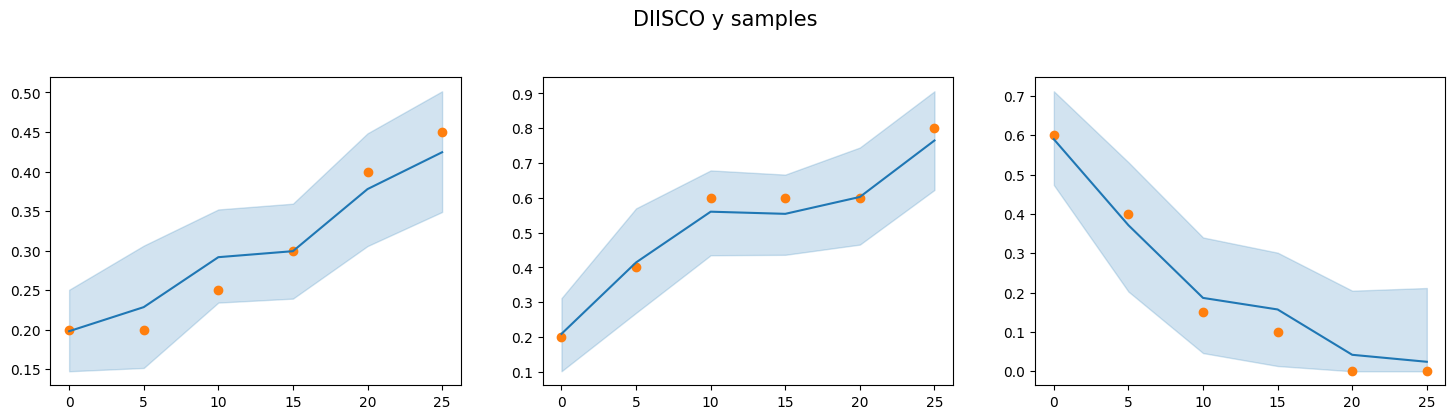

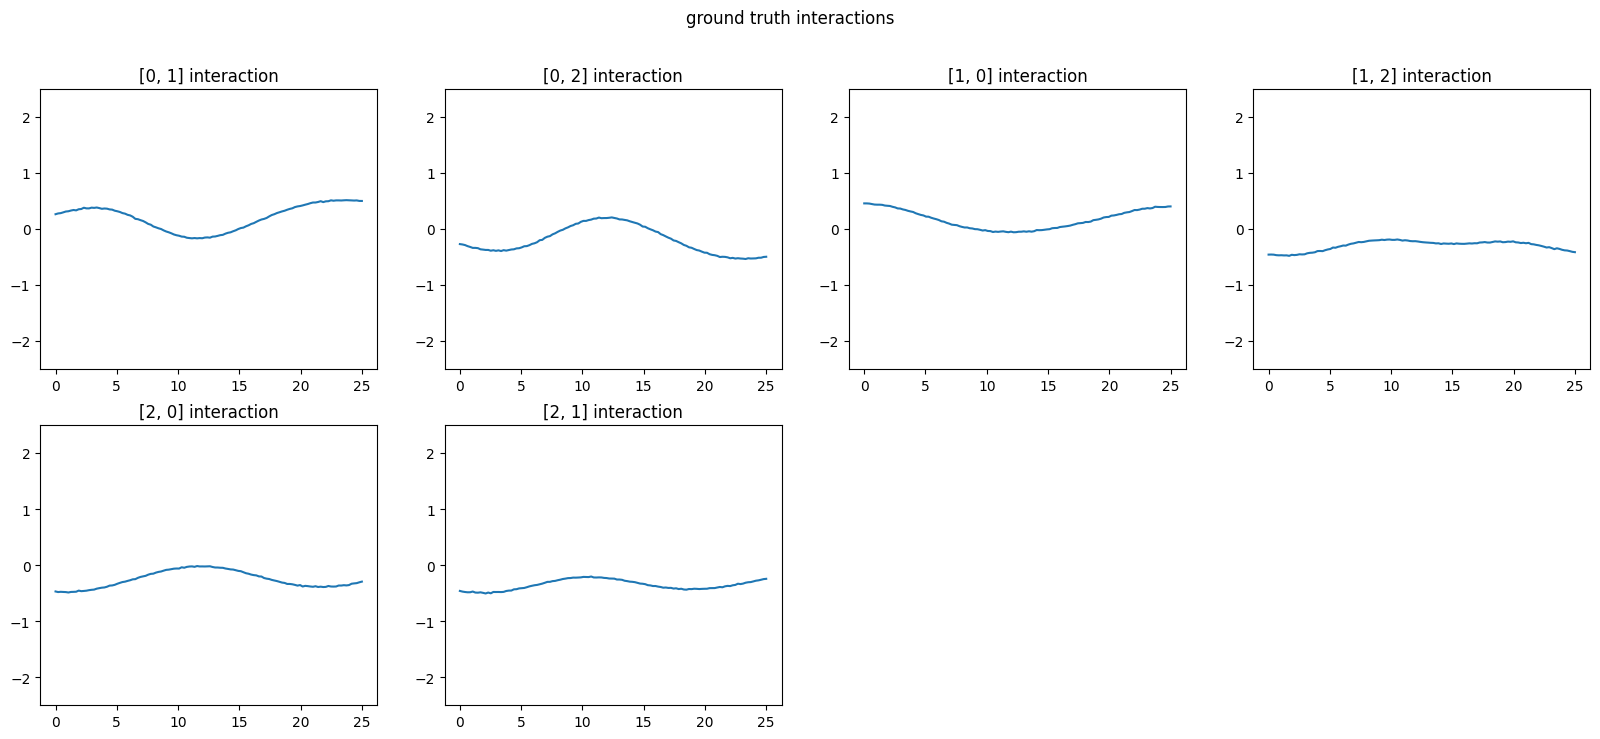

In [9]:
print(data.shape)
# lambda set here
model = DIISCO(lambda_matrix=lambda_prior, hypers_init_vals=hyper_init_vals, verbose=True, verbose_freq=100)

#model.fit_and_set_f_prior_params(timepoints=timepoints, proportions=proportions, hypers=model.hypers_init_vals)
model.fit_and_set_f_prior_params(timepoints=timepoints, signals=signal_t, proportions=proportions, hypers=model.hypers_init_vals)  
#model.fit(timepoints=timepoints, proportions=proportions,  n_iter=15000, lr=0.00005, guide="MultivariateNormalFactorized")
model.fit(timepoints=timepoints, signals=signal_t, proportions=proportions,  n_iter=15000, lr=0.00005, guide="MultivariateNormalFactorized")
        
true_observations = data
predicted_observations = model.sample_observed_proportions(n_samples=1000).detach()
print(predicted_observations.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i in range(3):
    cell_type_samples = predicted_observations[:, :, i]
    mean = unscale(cell_type_samples.mean(axis=0), i)
    percentile_75 = unscale(np.percentile(cell_type_samples, 84, axis=0), i)
    percentile_25 = unscale(np.percentile(cell_type_samples, 16, axis=0), i)
    axes[i].plot(timepoints, mean, c='tab:blue')
    axes[i].fill_between(timepoints.squeeze(), percentile_25, percentile_75, color='tab:blue', alpha=0.2)
    axes[i].scatter(timepoints, unscale(proportions[:, i], i), c='tab:orange')

plt.suptitle('DIISCO y samples', fontsize=15, y=1.05)
    
predict_timepoints = torch.linspace(timepoints.min(), timepoints.max(), 120).reshape(-1, 1)
predict_signals = np.concatenate((np.zeros(40), np.ones(80)), axis=0)
predict_signals = torch.tensor(predict_signals.reshape(-1, 1)).float()

samples = model.sample(predict_timepoints,
                       predict_signals,
                       n_samples=1000, 
                       n_samples_per_latent=10,
                       include_emission_variance=True)

W_samples_predict = samples['W']
f_samples_predict = samples['F']
y_samples_predict = samples['Y']
        
interaction_plots = []
for i in range(3):
    for j in range(3):
        # print(i,j)
        if i == j: continue
        w_pred = W_samples_predict[:, :,i, j].detach().numpy()
        if np.max(np.abs(w_pred)) > 0.005: 
            interaction_plots.append([i,j])
                    
n = len(interaction_plots); max_cols = 4
nrows = int(np.ceil(n / max_cols)); ncols = int(min((max_cols, n)))
fig = plt.figure(figsize=[5 * ncols, 4 * nrows])
for i,interaction in enumerate(interaction_plots):
    ax = fig.add_subplot(nrows, ncols, i+1)
    #ax.scatter(timepoints, proteins[:, interaction[0], interaction[1]], c='tab:orange')
    ax.plot(predict_timepoints, 
                    W_samples_predict[:, :,interaction[0], interaction[1]].mean(axis=0))
    ax.set_title(f'{interaction} interaction')
    ax.set_ylim(-2.5,2.5)
plt.suptitle("ground truth interactions")
plt.show()

Text(0.5, 1.05, 'DIISCO predicted interactions ($\\hat{W}_{avg})$')

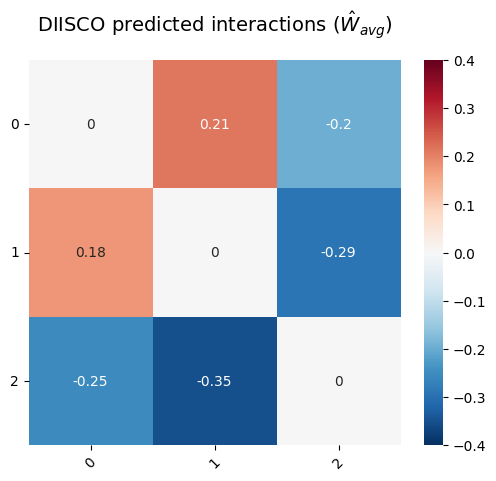

In [10]:
import seaborn as sns

plt.figure(figsize=(6, 5))
W_avg_over_time = W_samples_predict.mean(axis=(0, 1)).detach().numpy()
ax = sns.heatmap(W_avg_over_time, cmap="RdBu_r", annot=True, 
                 vmax=0.4, vmin=-0.4, center=0)
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.title('DIISCO predicted interactions ($\hat{W}_{avg})$', fontsize=14, y=1.05)
# 0 affected by: 2 pos
# 1 affected by: 0 pos
# 2 affected by: 0 neg

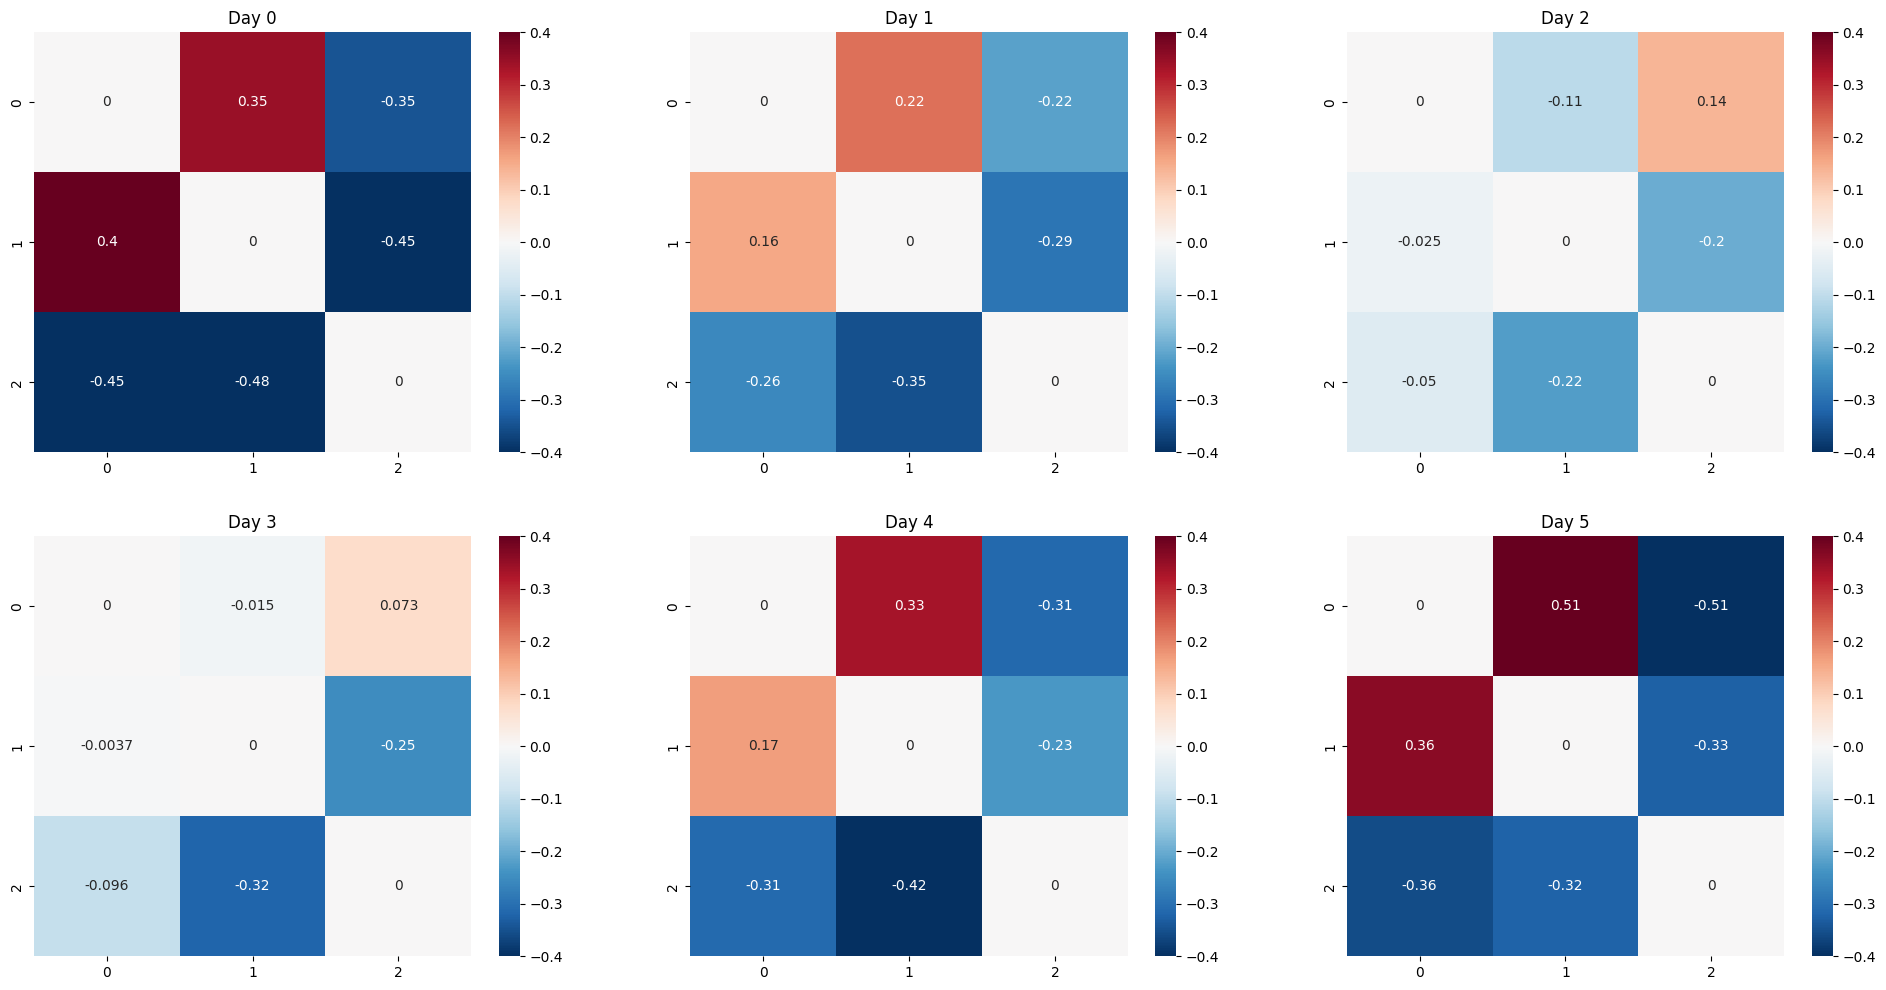

In [11]:
W_avg_per_timepoint = W_samples_predict.mean(axis=(0)).detach().numpy()
W_avg_1 = W_avg_per_timepoint[0:20].mean(axis=(0))
W_avg_2 = W_avg_per_timepoint[20:40].mean(axis=(0))
W_avg_3 = W_avg_per_timepoint[40:60].mean(axis=(0))
W_avg_4 = W_avg_per_timepoint[60:80].mean(axis=(0))
W_avg_5 = W_avg_per_timepoint[80:100].mean(axis=(0))
W_avg_6 = W_avg_per_timepoint[100:120].mean(axis=(0))

fig = plt.figure(figsize=(24, 12))
(row0,row1) = fig.subplots(2, 3)
sns.heatmap(W_avg_1, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row0[0])
row0[0].set_title("Day 0")

sns.heatmap(W_avg_2, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row0[1])
row0[1].set_title("Day 1")

sns.heatmap(W_avg_3, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row0[2])
row0[2].set_title("Day 2")

sns.heatmap(W_avg_4, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row1[0])
row1[0].set_title("Day 3")

sns.heatmap(W_avg_5, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row1[1])
row1[1].set_title("Day 4")

sns.heatmap(W_avg_6, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row1[2])
row1[2].set_title("Day 5")

plt.show()

In [12]:
print(str(W_avg_over_time[0][1]) + "," + str(W_avg_over_time[0][2]) + "," + str(W_avg_over_time[1][0]) + "," + str(W_avg_over_time[1][2])
       + "," + str(W_avg_over_time[2][0]) + "," + str(W_avg_over_time[2][1]))

0.21361601,-0.19616824,0.17594635,-0.29134753,-0.25434908,-0.35223415
